## <span style='text-decoration: double underline;color:rgb(10,110,217)'>**Results Model 101**</span>

**Loss function configuration:**

$\lambda_{init} = 1$  
$\lambda_{phys} = 0$  
$\lambda_{bin} = 1$

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import sys
sys.path.append('../')

In [3]:
import utils.evaluation_tools as eval_tools


delta = 1 
shape = (20,20)
model_name = 'ClassicBin'
parent_folder = '../Data'
seed2plot = 221
seeds = [221, 502, 700, 1204, 3340, 4501, 6054, 6621,8421, 15678, 19302, 38475, 77293, 91827, 99100]  

threshold = 0.5
figsize = (12,9)
subplots_grid = (3,3)
suptitle = 'ClassicBin Model'

th_ranges = [(0.45, 0.55), (0.40, 0.60), (0.35, 0.65)]

train_history_paths = eval_tools.get_paths_results('train_history.csv', parent_folder, seeds, shape, delta, model_name)
predictions_paths = eval_tools.get_paths_results('predictions.csv', parent_folder, seeds, shape, delta, model_name)
test_results_paths = eval_tools.get_paths_results('test_results.csv', parent_folder, seeds, shape, delta, model_name)
test_data = eval_tools.get_paths_results('test.npz', parent_folder, seeds, shape, delta, model_name) 

### <span style='color:rgb(10,110,217)'><u>**Train Results**</u></span>

--- Metrics computed during execution ---
loss: 0.3940 ± 0.0008
val_loss: 0.4018 ± 0.0016


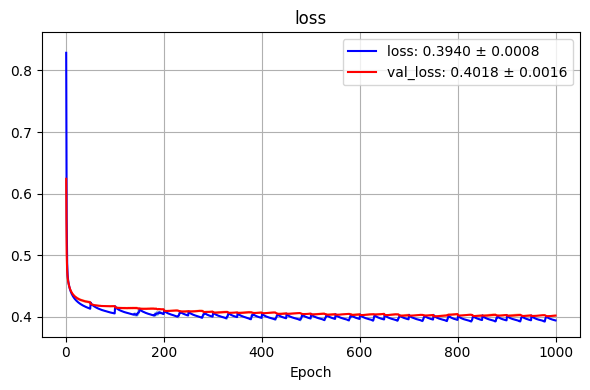

In [4]:
cols2omit = 1
num_rows = 1
eval_tools.display_results(train_history_paths, 'val_', cols2omit, num_rows, True, True)

### <span style='color:rgb(10,110,217)'><u>**Test Results**</u></span>

In [5]:
# Test:
eval_tools.display_results(test_results_paths, '_fin', display_plot=False)

--- Metrics computed during execution ---
Accuracy_init: 0.8713 ± 0.0004
Accuracy_fin: 0.8263 ± 0.0005
Recall_init: 0.6116 ± 0.0023
Recall_fin: 0.2014 ± 0.0026
Specificity_init: 0.9420 ± 0.0007
Specificity_fin: 0.9898 ± 0.0001
Precision_init: 0.7415 ± 0.0015
Precision_fin: 0.8375 ± 0.0017
F1Score_init: 0.6703 ± 0.0011
F1Score_fin: 0.3246 ± 0.0035


--- Results Initial States (15 seeds) ---
Density (true): 21.40% ± 8.99%
Density (pred): 19.04% ± 7.57%
Error/seed:     2.35% ± 0.06%
Max value predicted: 1.0000
HUC% (0.45, 0.55): 1.00% ± 0.02%
HUC% (0.4, 0.6): 2.06% ± 0.04%
HUC% (0.35, 0.65): 3.28% ± 0.06%
Fuzziness Index: 0.1906 ± 0.1080
MSE (prob):0.0989 ± 0.0588
MSE (bin):0.1287 ± 0.0777
MSE (all-zero): 0.2140 ± 0.0899
Wasserstein (EMD): 1.5861 ± 0.0052


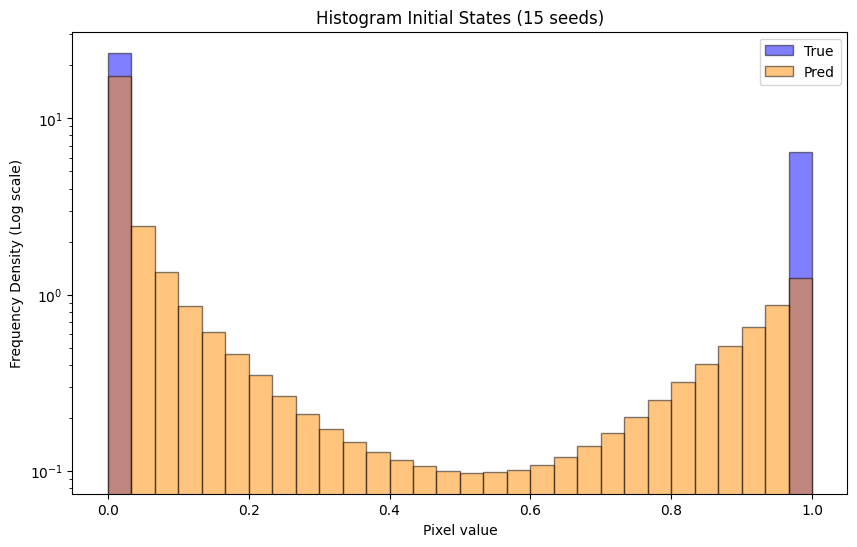

In [6]:
eval_tools.compute_metrics(predictions_paths, test_data,shape,'init', th_ranges, threshold, colors=['blue', 'darkorange'])

--- Results Final States (15 seeds) ---
Density (true): 20.74% ± 9.05%
Density (pred): 5.45% ± 1.81%
Error/seed:     15.28% ± 0.05%
Max value predicted: 1.0000
HUC% (0.45, 0.55): 1.08% ± 0.01%
HUC% (0.4, 0.6): 2.16% ± 0.02%
HUC% (0.35, 0.65): 3.26% ± 0.03%
Fuzziness Index: 0.0828 ± 0.0364
MSE (prob):0.1511 ± 0.0807
MSE (bin):0.1737 ± 0.0917
MSE (all-zero): 0.2074 ± 0.0905
Wasserstein (EMD): 3.1023 ± 0.0117


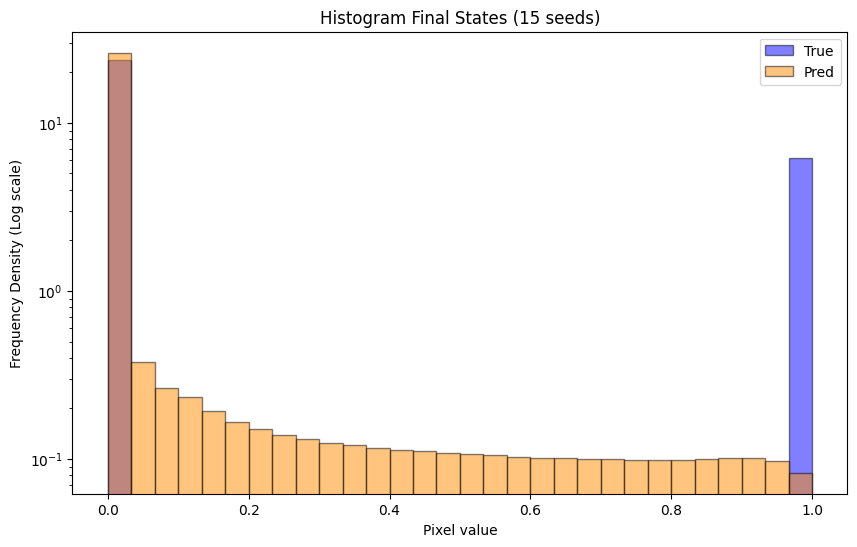

In [7]:
eval_tools.compute_metrics(predictions_paths, test_data,shape,'fin', th_ranges, threshold, colors=['blue', 'darkorange'])

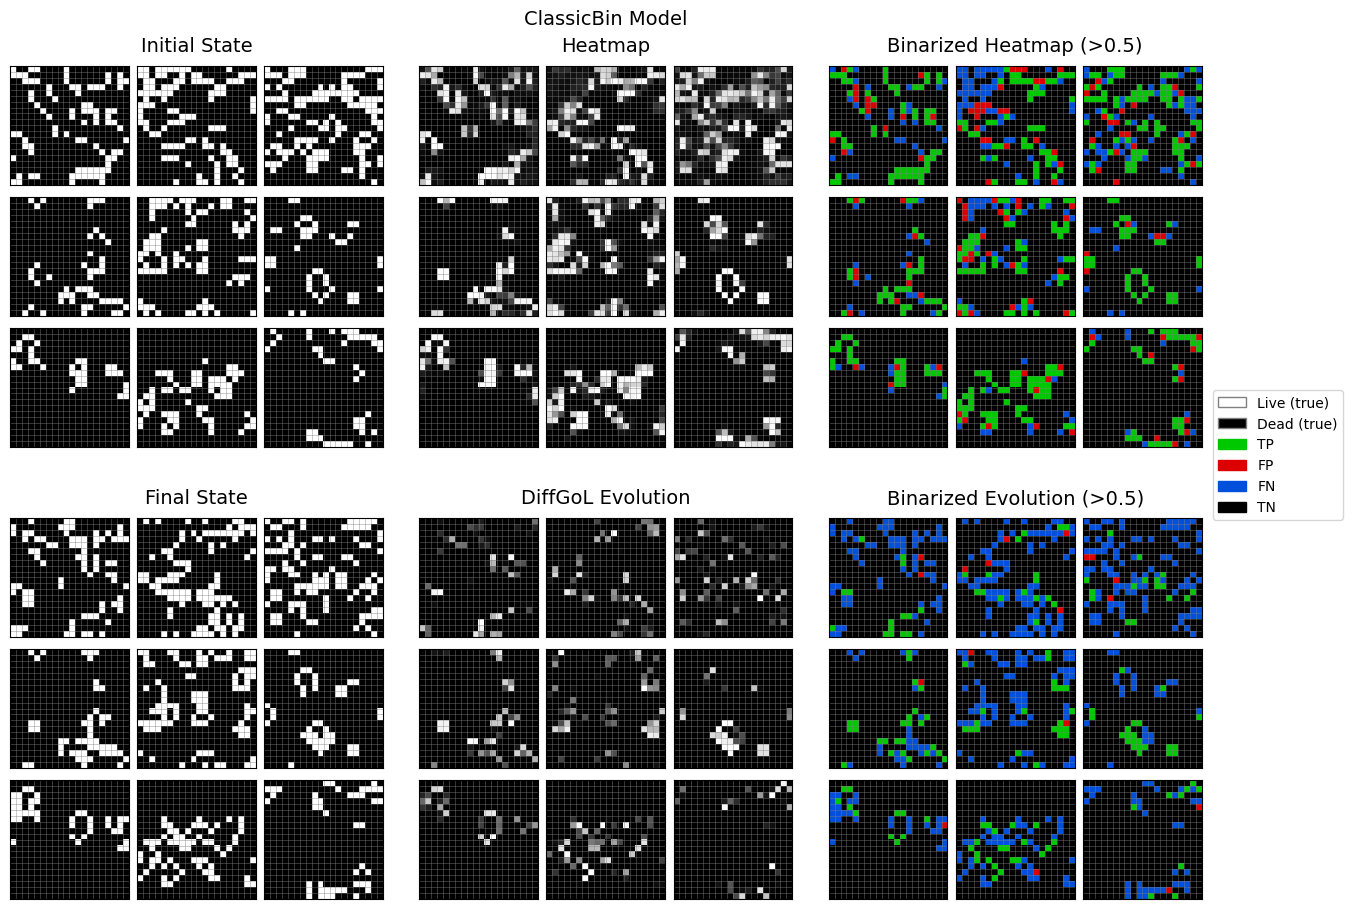

In [8]:
file_test = test_data[seed2plot]
file_pred = predictions_paths[seed2plot]
titles = ['Initial State', 'Heatmap', f'Binarized Heatmap (>{threshold})', 
          'Final State', 'DiffGoL Evolution', f'Binarized Evolution (>{threshold})']
eval_tools.display_states(file_pred, file_test, shape, threshold, titles, subplots_grid, suptitle, figsize, random=False)